# Titanic Survival Analysis
### Who Really Survived the Titanic?
Dataset sourced from Kaggle: https://www.kaggle.com/datasets/yasserh/titanic-dataset

The aim of this analysis is to unveil the answer to the question -- who survived the Titanic? By taking a deeper dive into the data of the passengers, we will see whether survival was random or were there some groups more likely to survive than others.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

### Loading the Dataset
The Titanic dataset contains passenger information such as:
- whether the passenger survived,
- their sex,
- age,
- ticket class,
- fare,
- and embarkation point.

Our goal is not to build a predictive model here. Instead, we want to use the data to explain any historical patterns.

In [3]:
df = pd.read_csv("C:\\Users\\jjani\\Downloads\\Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Simple Inspection / Cleaning
Before jumping into charts, it is helpful to understand:
how many rows and columns we have,
which columns contain missing values,
and the general structure of the dataset.
This gives us enough context to move into the story with confidence.

In [4]:
print(df.shape)
df.info()
df.describe()

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


We only address two missing-value issues:

Age: fill missing values with the median age
Embarked: fill missing values with the most common embarkation point
This allows us to use these variables in our visuals without overcomplicating the workflow.

In [5]:
# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

## First, how many people survived?

We start with first answering: What percentage of passengers survived at all?

This gives us the baseline for the rest of the analysis. If survival were close to 50/50, the story might feel balanced.
If survival were very low, then the next question becomes: who managed to survive?

Overall Survival Rate: 0.38


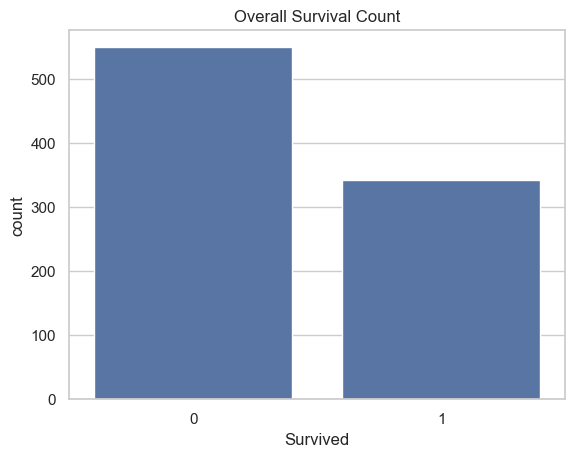

In [7]:
survival_rate = df['Survived'].mean()
print(f"Overall Survival Rate: {survival_rate:.2f}")

sns.countplot(x='Survived', data=df)
plt.title("Overall Survival Count")
plt.show()

The overall survival rate is well below half of all passengers.
That immediately tells us survival was rare, not common or typical.

This suggests that since most people did not survive, the passengers who did survive may have had some important advantage.
The next step is to figure out what those advantages were.

### Did Gender Matter?

It is a commonly told tale that women and children were prioritized, so we first take a look at the ratio of male to female survivors. If survival rates differ sharply between men and women, that would suggest evacuation was not random at all.

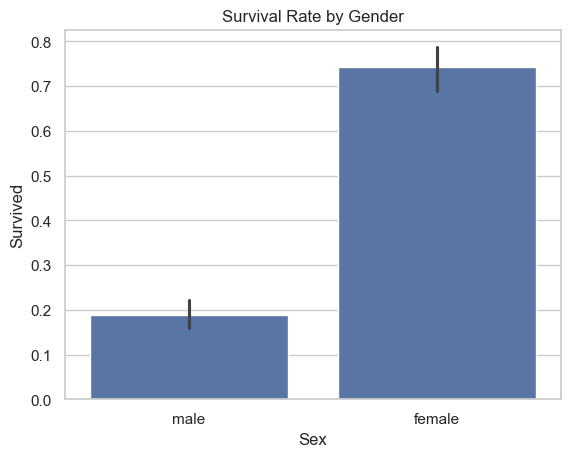

In [8]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title("Survival Rate by Gender")
plt.show()

Women survived at a much higher rate than men.
That suggests survival was shaped by social norms and evacuation priorities, not chance alone.

At this point, we already have evidence that:

survival was unequal,
and gender was a major factor.
But gender may not be the only factor.

### Did passenger class matter?

Next, we look at social class -- which we could account for by whether passengers held 1st class, 2nd class, or 3rd class tickets. Class is especially important because it can reflect access, privilege, and physical location on the ship.
If first-class passengers survived more often than third-class passengers, that would suggest the disaster exposed social inequality as well.

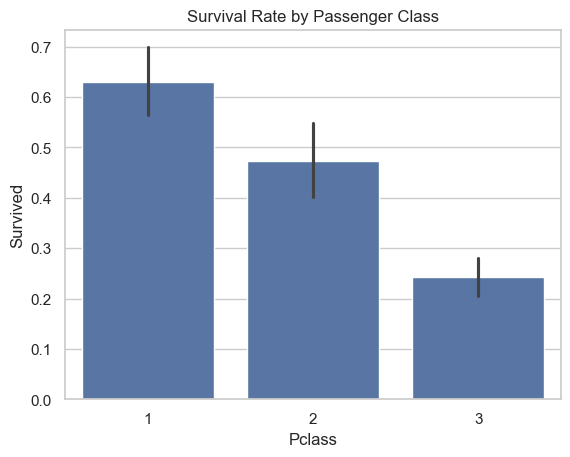

In [9]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()

It is clear that 1st class passengers had the highest survival rates and 3rd class passengers had the lowest survival rates.
This suggests that survival chances were connected not only to who you were, but also to where you stood in the ship’s social hierarchy.

So far, the data is pointing to a strong conclusion:

Survival on the Titanic was shaped by both gender and class privilege.

### What was the age distribution of the passengers like?

Before analyzing survival by age, it helps to understand the age distribution of the passengers overall. We must first figure out whether passengers mostly children, adult, or elderly.

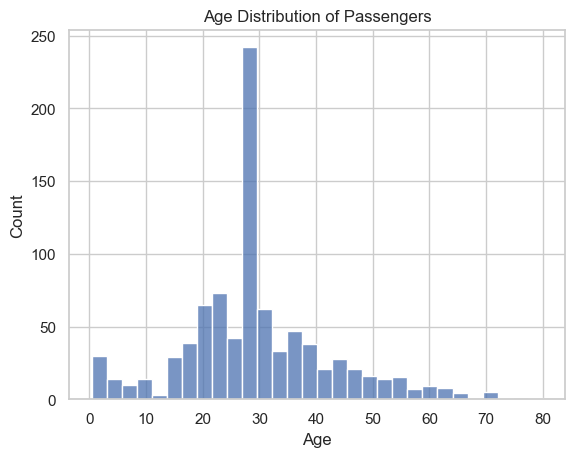

In [10]:
sns.histplot(df['Age'], bins=30)
plt.title("Age Distribution of Passengers")
plt.show()

Most passengers appear to fall in the young adult to adult range, with fewer children and fewer elderly passengers.

That means if children turn out to have higher survival rates, it would be especially notable because they represent a smaller share of the total passenger population.

### Did age matter?

To make it easier to compare survival patterns, we group passengers into the groups:

    Child
    Teen
    Young Adult
    Adult
    Senior

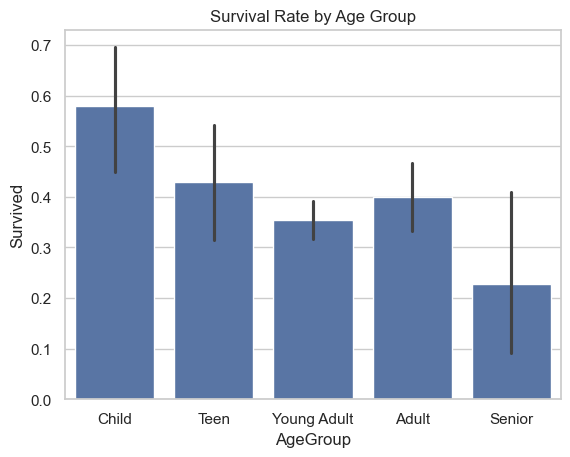

In [11]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,18,35,60,100],
                       labels=['Child','Teen','Young Adult','Adult','Senior'])

sns.barplot(x='AgeGroup', y='Survived', data=df)
plt.title("Survival Rate by Age Group")
plt.show()

Children show the strongest survival rate over the many groups. This supports the idea that evacuation may have prioritized younger passengers.

Age matters, but its effect is not as visually dramatic as gender or class. Still, it reinforces the narrative that some groups were clearly given better odds of survival than others.

### What if we look at gender and class together?

So far, we have examined gender and class separately. This final comparison combines both variables in one chart to help answer:

Who had the greatest advantage, and who had the least?

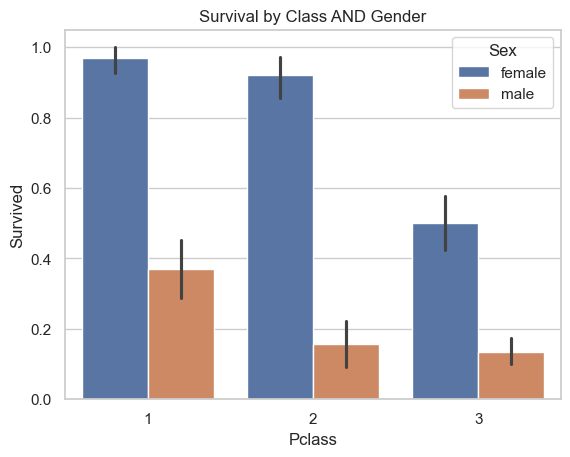

In [12]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df)
plt.title("Survival by Class AND Gender")
plt.show()

### Final Takeaways
This is the clearest storytelling chart so far.

It shows that:

Women in higher classes had the strongest survival odds.
Men in lower classes had the weakest survival odds.

To answer the question at the start-- No, survival was not determined by luck alone.
It was shaped by a combination of: mainly gender and social class, and to a lesser extent, age.

In [13]:
print("Key Insights:")
print("1. Women had significantly higher survival rates than men.")
print("2. First-class passengers were far more likely to survive.")
print("3. Children had better survival chances than adults.")
print("4. Third-class passengers had the lowest survival rates.")
print("5. Survival was strongly influenced by social and demographic factors.")

Key Insights:
1. Women had significantly higher survival rates than men.
2. First-class passengers were far more likely to survive.
3. Children had better survival chances than adults.
4. Third-class passengers had the lowest survival rates.
5. Survival was strongly influenced by social and demographic factors.
